## Calibration of the Heston Stochastic Volatility model on the S&P500 index through the SPX European vanilla options 

SPX options are European-style contracts and, unlike American options, are not subject to early exercise. As a result, their prices provide a cleaner representation of the market's expectations for the future dynamics of the S&P 500 index under the risk-neutral measure. By calibrating the Heston stochastic volatility model to the SPX implied volatility surface, the model parameters are chosen to reproduce observed market prices, yielding a market-consistent description of the index dynamics. Once calibrated, the model can be used to price other S&P 500-linked derivatives, such as American SPY options, using the same underlying stochastic volatility process, while accounting for differences in dividends and contract specifications.

Moreover, SPX options are among the most liquid index derivatives in the world, with deep order books and tight bid–ask spreads across a wide range of strikes and maturities. This exceptional liquidity ensures that market prices are both reliable and representative, providing a robust foundation for parameter calibration.

In this project, the Heston model is calibrated to SPX option data using Fourier-based European option pricing based on the Lewis formulation. The calibration is performed by minimizing the discrepancy between market and model-implied volatilities across the observed option surface.

In [1]:
#============================================
# Import packages
#============================================
import sys
sys.path.append("../fetch_data")
sys.path.append("../option_pricing_engine")
sys.path.append("../utils")
import math
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
np.set_printoptions(suppress=True,
formatter={'all': lambda x: '%5.3f' % x})
import pandas as pd
from scipy.optimize import brute, fmin, minimize
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'
from HestonFourierEuropean import H93_call_value
import SOFR_zero_rate
import YfinanceFetchData
import CalibrationFilter
from scipy.interpolate import CubicSpline
from BSM_imp_vol import implied_volatility
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import PchipInterpolator
from IPython.display import Math, display

---

### Risk-free rate

The Secured Overnight Financing Rate (SOFR) is used here to approximate the risk-free rate because it is based on transactions in the U.S. Treasury repurchase (repo) market, where borrowing is collateralized by U.S. government securities. As a result, SOFR contains minimal credit risk and reflects the prevailing cost of near risk-free funding in U.S. dollar markets. SOFR is the primary benchmark interest rate for the pricing and valuation of U.S. financial derivatives and fixed-income products. 

The most recent SOFR rate is used as a proxy for the risk-free interest rate. Since all options considered have maturities shorter than six months, the impact of interest-rate term-structure effects is expected to be small relative to other sources of pricing uncertainty, making a constant risk-free rate a reasonable approximation.

---

In [2]:
#========================================================================================
# Fetching all the options data for the S&P500 index, and the schedule for the dividends.
#========================================================================================
now = datetime.datetime.now()
if (now.weekday() < 5) and (11 <= now.hour < 16):
    live=True
else:
    live=False
full_options_data, div_schedule = YfinanceFetchData.main(ticker='^SPX', live=live)

  [dividends] no history found for ^SPX — assuming no dividends.


In [3]:
if live:
    today = datetime.date.today()
    with open("../options_data/saved_time.pkl", "wb") as file:
        pickle.dump(today, file)
    try:
        r = SOFR_zero_rate.get_sofr_rate([API_KEY_FOR_FRED])
    except NameError:
        r = np.load('../options_data/SOFR_rate.npy') # Uses saved SOFR rate if unable to get API key for FRED
else:
    with open("../options_data/saved_time.pkl", "rb") as file:
        today = pickle.load(file)
    r = np.load('../options_data/SOFR_rate.npy')

In [4]:
#----------------------------------------
# Dividend schedule for the SPX options
#----------------------------------------
div_schedule

array([], dtype=float64)

In [5]:
S0 = full_options_data['spot'][0] # Spot price of the ticker listed in the index data
print(S0)

7537.43017578125


In [6]:
#============================================
# Adding Short Rates
#============================================
full_options_data = full_options_data.drop(columns=['ticker',  'dividendRate', 'dividendYield'])
full_options_data = full_options_data[full_options_data['dte']>0]

---

### Determining the adjusted spot price for each option depending on its maturity

The spot price reported by the index data source may be stale relative to the option quotes, resulting in a lack of synchronization between the underlying index level and the observed option prices. This discrepancy can introduce errors when calibrating pricing models or extracting implied quantities directly from the reported spot price.

Although the constituent stocks of the S&P 500 index pay dividends, these dividend payments are not explicitly incorporated into the option data obtained from Yahoo Finance and hence, `div_schedule` is rather empty. To account for their effect, we infer a dividend-adjusted spot price using the European put–call parity relationship,

$$S_{\mathrm{adj}} = C - P + K e^{-rT}$$

where $C$ and $P$ denote the market prices of European call and put options with common strike $K$ and maturity $T$, respectively, and $r$ is the risk-free interest rate.

For European options, the option value depends only on the state of the underlying at maturity, since early exercise is not permitted. Consequently, the dividend-adjusted spot price $S_{\mathrm{adj}}$ encapsulates the combined effect of the current spot price and expected dividend payments over the life of the contract. As a result, European option pricing can be performed using $S_{\mathrm{adj}}$ directly, without requiring explicit knowledge of either the actual spot price $S_0$ or the dividend schedule. This approach is particularly convenient when dividend information is unavailable or difficult to estimate accurately.


In practice, at-the-money (ATM) options are used to compute the implied adjusted spot price for several reasons:

* They carry minimal intrinsic value, meaning their premium is predominantly driven by market-implied factors rather than payoff structure.
* The impact of implied volatility distortions is relatively small for ATM options compared to deep in-/out-of-the-money contracts.
* ATM options are typically the most liquid instruments, exhibiting the tightest bid–ask spreads and therefore providing more reliable price quotes.

In [7]:
#========================================================================================
# Filtering near-the-money options to find the adjusted spot price
#========================================================================================

def filter_near_atm_options(df, S0, moneyness_tol=0.01):
    """
    Filters ATM / near-ATM options.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain:
            - 'strike'
            - 'type'   ('call' or 'put')
            - 'expiry'

    S0 : float
        Current underlying spot price.

    moneyness_tol : float
        Allowed log-moneyness range.
        Example:
            0.05  -> approx ±5%
            0.10  -> approx ±10%

    Returns
    -------
    filtered_df : pandas.DataFrame
    """

    df = df.copy()
    #----------------
    # Log-moneyness
    #----------------
    df["log_moneyness"] = np.log(df["strike"] / S0)
    #-----------------------------
    # Keep only near-ATM options
    #-----------------------------
    filtered_df = df[np.abs(df["log_moneyness"]) <= moneyness_tol].copy()
    #---------------
    # Sort them
    #---------------
    filtered_df = filtered_df.sort_values(by=["dte", "strike", "type"]).reset_index(drop=True)
    return filtered_df

near_atm_options = filter_near_atm_options(full_options_data[full_options_data['dte'].between(40, 300)],S0=S0,moneyness_tol=0.01)
near_atm_options = near_atm_options[near_atm_options['volume']>5.]

In [8]:
near_atm_options

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,inTheMoney,log_moneyness
5,7537.4302,put,45,7475.0000,103.9900,106.0000,107.4000,106.7000,63.0000,0.1283,0.0000,-0.0083
6,7537.4302,call,45,7480.0000,202.8300,195.3000,196.9000,196.1000,7.0000,0.1566,1.0000,-0.0076
7,7537.4302,put,45,7480.0000,103.3000,107.5000,109.0000,108.2500,20.0000,0.1277,0.0000,-0.0076
9,7537.4302,put,45,7485.0000,105.2000,109.2000,110.7000,109.9500,31.0000,0.1272,0.0000,-0.0070
11,7537.4302,put,45,7490.0000,110.9100,110.5000,111.9000,111.2000,34.0000,0.1262,0.0000,-0.0063
...,...,...,...,...,...,...,...,...,...,...,...,...
577,7537.4302,call,283,7500.0000,595.4300,594.5000,597.7000,596.1000,20.0000,0.2190,1.0000,-0.0050
580,7537.4302,put,283,7525.0000,358.7300,357.1000,359.6000,358.3500,8.0000,0.1382,0.0000,-0.0017
581,7537.4302,call,283,7550.0000,511.9800,561.7000,564.8000,563.2500,8.0000,0.2153,0.0000,0.0017
584,7537.4302,put,283,7575.0000,442.4000,372.9000,375.7000,374.3000,7.0000,0.1343,1.0000,0.0050


In [9]:
def estimate_adjusted_spot(df, price_col="midPrice"):

    """
    Estimate adjusted spot price using put-call parity relation.

    Parameters
    ----------
    df : pandas.DataFrame

        Required columns:
            - expiry
            - strike
            - type
            - price_col (e.g. 'midPrice')

        type column should contain:
            'call' and 'put'

    S0 : float
        Current underlying spot price.

    r : float
        Continuously compounded risk-free rate.

    price_col : str
        Column containing option prices
        (recommended: midpoint prices).

    Returns
    -------
    Sadj_curve : DataFrame
        Adjusted spot price term
        structure.
    """

    df = df.copy()
    #----------------------
    # Split calls and puts
    #----------------------
    calls = df[df["type"] == 'call'].copy()
    puts  = df[df["type"] == 'put'].copy()
    #-----------------------
    # Rename price columns
    #-----------------------
    calls = calls.rename(columns={price_col: "C"})
    puts  = puts.rename(columns={price_col: "P"})
    #-----------------------------
    # Merge on expiry and strike
    #-----------------------------
    merged = pd.merge(calls[["dte", "strike", "C"]],
                      puts[["dte", "strike", "P"]],
                      on=["dte", "strike"],
                      how="inner")
    #---------------------------------------------
    # Implied dividend yield
    # S_adj = C - P + K*exp(-rT)
    #---------------------------------------------
    merged["Sadj"] = (merged["C"]- merged["P"]+ merged["strike"] * np.exp(-r * merged["dte"]/365.))
    #------------------------
    # Remove invalid values
    #------------------------
    merged = merged.replace([np.inf, -np.inf], np.nan)
    merged = merged.dropna(subset=["Sadj"])
    #-------------------------
    # Optional sanity filter
    #-------------------------
    use_median = True
    #-----------------------
    # Aggregate by expiry
    #-----------------------
    if use_median:
        Sadj_curve = (merged.groupby("dte")["Sadj"].median().reset_index())
    else:
        Sadj_curve = (merged.groupby("dte")["Sadj"].mean().reset_index())
    Sadj_curve = Sadj_curve.sort_values("dte")
    Sadj_curve = Sadj_curve.set_index("dte")
    return Sadj_curve

In [10]:
#=====================================================================
# Obtaining the adjusted spot price through near-the-money options.
#=====================================================================
Sadj_curve = estimate_adjusted_spot(near_atm_options)

In [11]:
Sadj_curve

,Sadj
dte,
45,7534.1059
52,7534.3868
55,7532.6748
73,7531.7268
85,7530.0940
101,7532.5356
115,7533.9606
136,7531.3502
164,7529.3735


In [12]:
#-------------------------------------------------------------------
# Performing interpolation to obtain the full term structure of
# the dividend-adjusted spot price
#-------------------------------------------------------------------
Sadj_interp_curve = PchipInterpolator(Sadj_curve.index.to_numpy(), np.array(Sadj_curve['Sadj']))

In [13]:
#================================================================================================
# Assigning the implied dividend-adjusted spot price to options based on their date of maturity.
#================================================================================================
def add_Sadj_nearest(df, Sadj_curve):
    """
    Assigns Sadj(T) from Sadj_curve to each option
    using nearest maturity match.

    Parameters
    ----------
    df : DataFrame
        Must contain 'dte'

    Sadj_curve : DataFrame
        Index = T (years), column = Sadj

    Returns
    -------
    df with new column 'Sadj'
    """
    df = df.copy()
    Sadj_map = Sadj_curve.iloc[:, 0]
    df["Sadj"] = df["dte"].map(Sadj_map)
    return df

full_options_data = add_Sadj_nearest(full_options_data, Sadj_curve)

In [14]:
full_options_data

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,inTheMoney,Sadj
358,7537.4302,put,1,3400.0000,0.0500,0.0000,0.0500,0.0250,1.0000,2.8906,0.0000,NaN
359,7537.4302,put,1,3600.0000,0.1000,0.0000,0.0500,0.0250,10.0000,2.6875,0.0000,NaN
360,7537.4302,put,1,3800.0000,0.1000,0.0000,0.0500,0.0250,1.0000,2.5000,0.0000,NaN
361,7537.4302,put,1,4000.0000,0.1000,0.0000,0.0500,0.0250,1.0000,2.3125,0.0000,NaN
362,7537.4302,put,1,4200.0000,0.1000,0.0000,0.0500,0.0250,2.0000,2.1484,0.0000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18985,7537.4302,put,1991,16000.0000,5465.4800,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,NaN
18986,7537.4302,call,1991,18000.0000,45.1600,0.0000,0.0000,0.0000,1.0000,0.0625,0.0000,NaN
18987,7537.4302,put,1991,18000.0000,6865.6400,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,NaN
18988,7537.4302,call,1991,20000.0000,28.7000,0.0000,0.0000,0.0000,79.0000,0.0625,0.0000,NaN


We are filtering the options which are relevant for the calibration of the Heston stochastic volatility model:
* The days to expiry is in the range of 30 to 250 days that helps in identifying the term structure of mean-reversion and the volatility of volatility.
* Only OTM options are chosen since they have better liquidy and isolate the market's true expectation of volatility from the asset's intrinsic value. It also avoids the put-call parity redundancy.
* Moneyness in the range of 0.80 to 1.25, Bid $>$ 0, Bid-Ask spread $\leq$ $20\%$ of Mid, and Volume $\geq$ $10$ to obtain highly liquid options.
* Implied volatility $\sim$ $0.01-2$ to drop the numerical artefacts.

In [15]:
#==================================================================================
# Filtering out the options that are relevant for calibrating the Heston SV model.
#==================================================================================
options_data = CalibrationFilter.heston_filter(full_options_data)


  Applying Heston filters …
    [18632]  start
    [9586]  DTE 30–300 days
    [7288]  moneyness 0.8–1.25
    [4170]  OTM only (calls K≥spot, puts K<spot)
    [4168]  bid > 0.0
    [4138]  midPrice ≥ $0.5
    [4062]  spread ≤ 15% of mid
    [1461]  volume ≥ 10
    [1461]  IV 5%–150%

  Heston calibration set — 1461 contracts
     DTE   Puts  Calls  Total    Moneyness range
  --------------------------------------------------------
      30     15      7     22    0.919 – 1.061
      31     71     27     98    0.803 – 1.075
      34     15      8     23    0.836 – 1.061
      35      3      0      3    0.889 – 0.969
      36      1      0      1    0.962 – 0.962
      38     45     14     59    0.803 – 1.081
      45    135     57    192    0.800 – 1.088
      52     22      8     30    0.816 – 1.081
      55     90     54    144    0.800 – 1.111
      73     95     50    145    0.800 – 1.134
      85     75     22     97    0.804 – 1.121
     101     71     30    101    0.806 – 1.168


In [16]:
options_data

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spread_pct,inTheMoney,Sadj
0,7537.4302,put,30,6925.0000,15.1800,13.4000,14.1000,13.7500,11.0000,0.2014,0.9187,0.0509,0.0000,NaN
1,7537.4302,put,30,6950.0000,14.4000,14.3000,15.0000,14.6500,17.0000,0.1977,0.9221,0.0478,0.0000,NaN
2,7537.4302,put,30,6975.0000,16.0000,15.4000,16.1000,15.7500,45.0000,0.1943,0.9254,0.0444,0.0000,NaN
3,7537.4302,put,30,7050.0000,19.2300,19.0000,19.7000,19.3500,11.0000,0.1835,0.9353,0.0362,0.0000,NaN
4,7537.4302,put,30,7075.0000,20.6700,20.6000,21.3000,20.9500,42.0000,0.1803,0.9386,0.0334,0.0000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,7537.4302,call,283,8800.0000,72.7000,71.9000,73.5000,72.7000,36.0000,0.1563,1.1675,0.0220,0.0000,NaN
1457,7537.4302,call,283,8900.0000,60.2900,58.3000,59.8000,59.0500,25.0000,0.1542,1.1808,0.0254,0.0000,NaN
1458,7537.4302,call,283,9200.0000,26.1400,30.4000,31.5000,30.9500,92.0000,0.1497,1.2206,0.0355,0.0000,NaN
1459,7537.4302,call,283,9300.0000,25.4200,24.3000,25.4000,24.8500,84.0000,0.1487,1.2338,0.0443,0.0000,NaN


Determining the call value of the equivalent put options obtained through the put-call parity relation:
$$C(K, T) = P(K, T) + S_\text{adj} -K e^{-rT}$$

In [17]:
#================================================================================================
# Using put–call parity relation to determine the equivalent call option value from a put option.
#================================================================================================
options_data['call_value'] = options_data.apply(lambda row: 
                                                row['midPrice'] if row['type'] == 'call' 
                                                else row['midPrice'] + row['Sadj']
                                                - row['strike'] * np.exp(-r * row['dte']/365.), axis=1)

In [18]:
options_data

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spread_pct,inTheMoney,Sadj,call_value
0,7537.4302,put,30,6925.0000,15.1800,13.4000,14.1000,13.7500,11.0000,0.2014,0.9187,0.0509,0.0000,NaN,NaN
1,7537.4302,put,30,6950.0000,14.4000,14.3000,15.0000,14.6500,17.0000,0.1977,0.9221,0.0478,0.0000,NaN,NaN
2,7537.4302,put,30,6975.0000,16.0000,15.4000,16.1000,15.7500,45.0000,0.1943,0.9254,0.0444,0.0000,NaN,NaN
3,7537.4302,put,30,7050.0000,19.2300,19.0000,19.7000,19.3500,11.0000,0.1835,0.9353,0.0362,0.0000,NaN,NaN
4,7537.4302,put,30,7075.0000,20.6700,20.6000,21.3000,20.9500,42.0000,0.1803,0.9386,0.0334,0.0000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,7537.4302,call,283,8800.0000,72.7000,71.9000,73.5000,72.7000,36.0000,0.1563,1.1675,0.0220,0.0000,NaN,72.7000
1457,7537.4302,call,283,8900.0000,60.2900,58.3000,59.8000,59.0500,25.0000,0.1542,1.1808,0.0254,0.0000,NaN,59.0500
1458,7537.4302,call,283,9200.0000,26.1400,30.4000,31.5000,30.9500,92.0000,0.1497,1.2206,0.0355,0.0000,NaN,30.9500
1459,7537.4302,call,283,9300.0000,25.4200,24.3000,25.4000,24.8500,84.0000,0.1487,1.2338,0.0443,0.0000,NaN,24.8500


In [19]:
options_data = options_data[options_data.groupby('dte')['dte'].transform('count') >= 30]
options_data

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spread_pct,inTheMoney,Sadj,call_value
22,7537.4302,put,31,6050.0000,3.2500,3.2000,3.4000,3.3000,11.0000,0.3390,0.8027,0.0606,0.0000,NaN,NaN
23,7537.4302,put,31,6100.0000,3.5000,3.4000,3.6000,3.5000,24.0000,0.3305,0.8093,0.0571,0.0000,NaN,NaN
24,7537.4302,put,31,6200.0000,4.2000,3.9000,4.2000,4.0500,12.0000,0.3152,0.8226,0.0741,0.0000,NaN,NaN
25,7537.4302,put,31,6300.0000,4.6000,4.5000,4.8000,4.6500,19.0000,0.2987,0.8358,0.0645,0.0000,NaN,NaN
26,7537.4302,put,31,6350.0000,4.9000,4.8000,5.2000,5.0000,24.0000,0.2910,0.8425,0.0800,0.0000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,7537.4302,call,283,8800.0000,72.7000,71.9000,73.5000,72.7000,36.0000,0.1563,1.1675,0.0220,0.0000,NaN,72.7000
1457,7537.4302,call,283,8900.0000,60.2900,58.3000,59.8000,59.0500,25.0000,0.1542,1.1808,0.0254,0.0000,NaN,59.0500
1458,7537.4302,call,283,9200.0000,26.1400,30.4000,31.5000,30.9500,92.0000,0.1497,1.2206,0.0355,0.0000,NaN,30.9500
1459,7537.4302,call,283,9300.0000,25.4200,24.3000,25.4000,24.8500,84.0000,0.1487,1.2338,0.0443,0.0000,NaN,24.8500


In [22]:
unique_options_expiry = full_options_data['dte'].unique()
unique_options_expiry

array([1.000, 2.000, 3.000, 6.000, 7.000, 8.000, 9.000, 10.000, 13.000,
       14.000, 15.000, 16.000, 17.000, 20.000, 21.000, 22.000, 23.000,
       24.000, 27.000, 28.000, 29.000, 30.000, 31.000, 34.000, 35.000,
       36.000, 38.000, 45.000, 52.000, 55.000, 73.000, 85.000, 101.000,
       115.000, 136.000, 146.000, 164.000, 177.000, 192.000, 227.000,
       255.000, 267.000, 283.000, 318.000, 345.000, 358.000, 374.000,
       437.000, 528.000, 710.000, 892.000, 1263.000, 1627.000, 1991.000])

---

# Heston Stochastic Volatility Model for Fourier Pricing of European Options

The Heston stochastic volatility (SV) model extends the Black-Scholes framework by allowing the variance of the underlying asset to evolve as a stochastic process rather than remaining constant through time. This enables the model to capture important market phenomena such as volatility smiles and skews, which cannot be reproduced by the constant-volatility assumption of Black-Scholes.

Under the Heston model, the asset price, $S(t)$ and instantaneous variance, $v(t)$ evolve according to

$$dS(t)=S(t)\left(\mu dt + \sqrt{v(t)},dW_1(t)\right)$$

$$dv(t)=\kappa_v\bigl(\theta_v-v(t)\bigr)dt+\sigma_v\sqrt{v(t)}dW_2(t)$$

where $ \rho \equiv \mathrm{Corr}(dW_1,dW_2)$ denotes the correlation between shocks to the asset price and variance.

The model parameters have the following interpretations:

* $\kappa_v$: speed of mean reversion of the variance process,
* $\theta_v$: long-run variance level,
* $\sigma_v$: volatility of variance (vol-of-vol),
* $\rho$: correlation between asset returns and variance,
* $v_0$: initial variance.

A major advantage of the Heston model is that it admits a semi-analytical valuation formula through the characteristic function of the log-asset price. Consequently, European options can be priced efficiently using Fourier inversion techniques, making the model particularly suitable for calibration to large option datasets.

The Heston (1993) characteristic function is given by
$\phi_0^{H93}(u,T)= e^{H_1(u,T)+H_2(u,T)v_0}$
where
$$H_1(u,T) = r_{0,T}uiT + \frac{c_1}{\sigma_v^2} \left[ (\kappa_v-\rho\sigma_v ui+c_2)T-2\ln\left(\frac{1-c_3e^{c_2T}}{1-c_3}\right)\right]$$
$$H_2(u,T)=\frac{\kappa_v-\rho\sigma_v ui+c_2}{\sigma_v^2}\left[\frac{1-e^{c_2T}}{1-c_3e^{c_2T}}\right]$$
with
$$c_1=\kappa_v\theta_v$$
$$c_2=-\sqrt{(\rho\sigma_v ui-\kappa_v)^2-\sigma_v^2(-ui-u^2)}$$
and
$$c_3=\frac{\kappa_v-\rho\sigma_v ui+c_2}{\kappa_v-\rho\sigma_v ui-c_2}$$
Since the characteristic function involves complex logarithms and square roots, branch-cut ambiguities may arise. Throughout this work, the principal branch is used consistently.

Using the characteristic function, the value of a European call option can be expressed as
$$C =\max\left(0,,S_0-e^{-rT}\frac{\sqrt{S_0K}}{\pi}\int_0^\infty\frac{\Re\left[\left(\frac{S_0}{K}\right)^{iu}\phi_0^{H93}\left(u-\frac{i}{2},T\right)\right]}{u^2+\frac14},du\right)$$
This formulation reduces the valuation problem to a one-dimensional numerical integration and is substantially more efficient than Monte Carlo simulation when pricing large numbers of European options during model calibration.

---

## Model Calibration

Rather than quoting option prices directly, market participants often express option values in terms of their **implied volatility**. Implied volatility is the volatility parameter that, when substituted into the Black-Scholes formula, reproduces the observed market price of an option. Implied volatility is preferred for calibration because option prices vary significantly across strikes, maturities, and moneyness levels. A fixed pricing error may be negligible for an expensive option but substantial for a cheap one. Converting prices to implied volatilities normalizes these effects and allows calibration errors to be compared consistently across the entire option surface. Furthermore, the volatility smile and term structure observed in the market are more naturally represented in implied-volatility space than in price space.

The Heston model parameters are estimated by fitting model-implied volatilities to observed market implied volatilities. The calibration problem is formulated as
$$\underset{\kappa_v,\theta_v,\sigma_v,\rho,v_0}{\operatorname{argmin}}\sum_i\left(\sigma_i^{\text{mkt}}-\sigma_i^{H93}\right)^2,$$
where $\sigma_i^{\text{mkt}}$ denotes the observed market implied volatility of the $i$-th option and $\sigma_i^{H93}$ is the corresponding implied volatility generated by the Heston model.

However, a naive minimization of this objective often leads to economically implausible parameter values, as the optimizer attempts to overfit the volatility surface—typically pushing parameters such as $\kappa_v$
 and $\sigma_v$ into unrealistic regimes.

To improve the stability of the calibration procedure and mitigate parameter degeneracy, the objective function is regularized through the addition of penalty terms, yielding
$$\underset{\kappa_v,\theta_v,\sigma_v,\rho,v_0}{\operatorname{argmin}}
\sum_i w_i\left(\sigma_i^{\mathrm{mkt}}-\sigma_i^{\mathrm{H93}}\right)^2+ \lambda_{\mathrm{Feller}}(F-0.3)^2
+\lambda_{\sigma}(\sigma_v-1.2)^2$$

where $w_i \propto \sqrt{T_i}$ are weights that approximate a vega-weighted least-squares criterion, and $F=\frac{2\kappa_v\theta_v}{\sigma_v^2}$ denotes the Feller ratio. The additional penalty terms act as soft constraints, discouraging parameter combinations that violate known stability conditions or lead to economically implausible dynamics. In particular, the Feller penalty promotes variance processes that remain strictly positive, while the vol-of-vol penalty prevents unrealistically large values of $\sigma_v$ that can arise during unconstrained calibration.

It is worth noting that empirical equity-option data frequently favour parameter sets that violate the Feller condition, especially when a large vol-of-vol parameter is required to reproduce the pronounced curvature and skew observed in the implied-volatility surface. Consequently, the regularization terms are designed to guide the optimization toward stable and interpretable solutions without imposing hard constraints that could significantly degrade the quality of the fit.


To improve robustness and reduce the likelihood of converging to suboptimal local minima, a two-stage optimization procedure is employed. A global optimization algorithm is first used to identify a promising region of the parameter space, after which a local optimization routine refines the solution and determines the final calibrated parameter set.

---

## Selection of Calibration Instruments

The Heston model is most effective for medium- and long-dated equity options. Short-dated options often exhibit pronounced volatility smiles driven by jump risk and other market effects that cannot be fully captured by a pure stochastic-volatility framework. Including such options in the calibration can lead to unstable parameter estimates and unrealistically low Feller ratios.

For this reason, the calibration is restricted to a medium-term maturity bucket consisting of options with maturities between 90 and 240 days. This range provides a liquid and representative dataset while remaining well suited to the assumptions underlying the Heston stochastic volatility model. Here, choose the range of 3-8 months for calibration since this is the range where the smile has subsided and the option chain is liquid enough.

Slightly out-of-the-money (OTM) options are typically the most actively traded and therefore dominate listed option datasets. If calibration is performed without care, the objective function tends to be disproportionately influenced by these liquid strikes, leading to a fit that is overly tailored to a narrow region of the implied volatility surface.

To mitigate this bias, options are selected to be as evenly distributed across strike levels as possible. This uniform sampling across moneyness ensures that the calibration procedure assigns comparable weight to different regions of the volatility surface, rather than concentrating primarily on the most liquid contracts. As a result, the calibrated parameters exhibit improved stability and generalisation across both low- and high-strike regimes, leading to a more robust representation of the full implied volatility structure.


In [31]:
#==================================================================================================
# Filtering options chain with maturities spanning 5 different expiration dates which are
# closest to the target days to expiry.
#==================================================================================================
#--------------------------------
# Number of unique expiry dates
#--------------------------------
main_array = np.array(options_data['dte'].unique())
#----------------------------------------------
# Target days to expiry for model calibration
#----------------------------------------------
#targets = np.array([105, 119, 140, 168, 196])
#targets = unique_options_expiry[unique_options_expiry>90 & unique_options_expiry <240]
targets = np.sort(np.random.default_rng().choice(unique_options_expiry[(unique_options_expiry>90) &\
                                                 (unique_options_expiry<240)], size=5, replace=False))
#-------------------------------------------------------------------
# Compute absolute differences between all targets and all elements
#-------------------------------------------------------------------
diff = np.abs(main_array[:, np.newaxis] - targets)
#-------------------------------------------------------------------
# Find the index of the minimum difference for each target
#-------------------------------------------------------------------
closest_indices = np.argmin(diff, axis=0)
#--------------------------------
# Retrieve the closest values
#--------------------------------
calib_dte_values = main_array[closest_indices]
#---------------------------------------------------------
# Filtering the options data for the selected maturities
#---------------------------------------------------------
options_data_filt_1 = options_data[options_data['dte'].isin(calib_dte_values)] 

In [32]:
options_data_filt_1

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,moneyness,spread_pct,inTheMoney,Sadj,call_value
915,7537.4302,put,115,6125.0000,44.0500,34.2000,34.9000,34.5500,25.0000,0.2595,0.8126,0.0203,0.0000,7533.9606,1513.3538
916,7537.4302,put,115,6375.0000,54.0000,45.5000,46.4000,45.9500,12.0000,0.2370,0.8458,0.0196,0.0000,7533.9606,1277.6046
917,7537.4302,put,115,6450.0000,51.0000,49.7000,50.7000,50.2000,116.0000,0.2303,0.8557,0.0199,0.0000,7533.9606,1207.7098
918,7537.4302,put,115,6475.0000,51.0700,51.2000,52.2000,51.7000,16.0000,0.2281,0.8590,0.0193,0.0000,7533.9606,1184.4949
919,7537.4302,put,115,6500.0000,52.5700,52.8000,53.8000,53.3000,17.0000,0.2258,0.8624,0.0188,0.0000,7533.9606,1161.3799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,7537.4302,call,227,8525.0000,61.4700,77.4000,78.9000,78.1500,12.0000,0.1536,1.1310,0.0192,0.0000,7537.2046,78.1500
1314,7537.4302,call,227,8600.0000,55.5200,65.0000,66.5000,65.7500,223.0000,0.1519,1.1410,0.0228,0.0000,7537.2046,65.7500
1315,7537.4302,call,227,8800.0000,41.5000,40.0000,41.1000,40.5500,319.0000,0.1479,1.1675,0.0271,0.0000,7537.2046,40.5500
1316,7537.4302,call,227,8900.0000,31.8000,31.0000,32.0000,31.5000,23.0000,0.1463,1.1808,0.0317,0.0000,7537.2046,31.5000


In [33]:
#==================================================================================================
# Filtering the options data for the selected `m` number of strikes. Selecting few strikes from 
# extreme end and the remaining uniformly
#==================================================================================================

def select_strike(group):
    m = 15
    arr = group['strike'].unique()
    n = len(arr)
    #---------------------------------------
    # Find the index closest to center_val
    #---------------------------------------
    corner_indices = np.array([0, n-2 ,n-1])
    target_strikes = np.linspace(arr[3], arr[n-3], m-3, endpoint=True, dtype=float)
    middle_indices = np.searchsorted(arr, target_strikes)
    left_diffs = np.abs(arr[middle_indices - 1] - target_strikes)
    right_diffs = np.abs(arr[middle_indices] - target_strikes)

    middle_indices = np.where(left_diffs < right_diffs, middle_indices - 1, middle_indices)
    #---------------------
    # Combine everything
    #---------------------
    all_indices = np.sort(np.concatenate([corner_indices, middle_indices]))
    filt_arr = [arr[i] for i in all_indices]
    return group[group['strike'].isin(filt_arr)]
calib_options_data = options_data_filt_1.groupby('dte').apply(select_strike)

In [34]:
calib_options_data

spot  type  dte    strike  lastPrice      bid      ask  midPrice   volume  impliedVolatility  moneyness  spread_pct  inTheMoney      Sadj  \
dte                                                                                                                                                       
115 915  7537.4302   put  115 6125.0000    44.0500  34.2000  34.9000   34.5500  25.0000             0.2595     0.8126      0.0203      0.0000 7533.9606   
    918  7537.4302   put  115 6475.0000    51.0700  51.2000  52.2000   51.7000  16.0000             0.2281     0.8590      0.0193      0.0000 7533.9606   
    920  7537.4302   put  115 6700.0000    67.5700  67.6000  68.7000   68.1500  18.0000             0.2080     0.8889      0.0161      0.0000 7533.9606   
    924  7537.4302   put  115 6860.0000    95.3400  83.0000  84.1000   83.5500  11.0000             0.1935     0.9101      0.0132      0.0000 7533.9606   
    925  7537.4302   put  115 7020.0000   101.6700 102.7000 103.9000  103.3000  80.0000             0.1790     0.9314      0.0116      0.0000 7533.9606   
...            ...   ...  ...       ...        ...      ...      ...       ...      ...                ...        ...         ...         ...       ...   
227 1310 7537.4302  call  227 8400.0000   105.3200 102.7000 104.2000  103.4500 168.0000             0.1571     1.1144      0.0145      0.0000 7537.2046   
    1314 7537.4302  call  227 8600.0000    55.5200  65.0000  66.5000   65.7500 223.0000             0.1519     1.1410      0.0228      0.0000 7537.2046   
    1315 7537.4302  call  227 8800.0000    41.5000  40.0000  41.1000   40.5500 319.0000             0.1479     1.1675      0.0271      0.0000 7537.2046   
    1316 7537.4302  call  227 8900.0000    31.8000  31.0000  32.0000   31.5000  23.0000             0.1463     1.1808      0.0317      0.0000 7537.2046   
    1317 7537.4302  call  227 9000.0000    24.8400  23.8000  24.8000   24.3000 158.0000             0.1450     1.1940      0.0412      0.0000 7537.2046   

          call_value  
dte                   
115 915    1513.3538  
    918    1184.4949  
    920     978.5105  
    924     835.7350  
    925     697.3095  
...              ...  
227 1310    103.4500  
    1314     65.7500  
    1315     40.5500  
    1316     31.5000  
    1317     24.3000  

[75 rows x 15 columns]

In [35]:
calib_options_data = calib_options_data[calib_options_data['midPrice']>0.0001]

In [36]:
calib_options_data

spot  type  dte    strike  lastPrice      bid      ask  midPrice   volume  impliedVolatility  moneyness  spread_pct  inTheMoney      Sadj  \
dte                                                                                                                                                       
115 915  7537.4302   put  115 6125.0000    44.0500  34.2000  34.9000   34.5500  25.0000             0.2595     0.8126      0.0203      0.0000 7533.9606   
    918  7537.4302   put  115 6475.0000    51.0700  51.2000  52.2000   51.7000  16.0000             0.2281     0.8590      0.0193      0.0000 7533.9606   
    920  7537.4302   put  115 6700.0000    67.5700  67.6000  68.7000   68.1500  18.0000             0.2080     0.8889      0.0161      0.0000 7533.9606   
    924  7537.4302   put  115 6860.0000    95.3400  83.0000  84.1000   83.5500  11.0000             0.1935     0.9101      0.0132      0.0000 7533.9606   
    925  7537.4302   put  115 7020.0000   101.6700 102.7000 103.9000  103.3000  80.0000             0.1790     0.9314      0.0116      0.0000 7533.9606   
...            ...   ...  ...       ...        ...      ...      ...       ...      ...                ...        ...         ...         ...       ...   
227 1310 7537.4302  call  227 8400.0000   105.3200 102.7000 104.2000  103.4500 168.0000             0.1571     1.1144      0.0145      0.0000 7537.2046   
    1314 7537.4302  call  227 8600.0000    55.5200  65.0000  66.5000   65.7500 223.0000             0.1519     1.1410      0.0228      0.0000 7537.2046   
    1315 7537.4302  call  227 8800.0000    41.5000  40.0000  41.1000   40.5500 319.0000             0.1479     1.1675      0.0271      0.0000 7537.2046   
    1316 7537.4302  call  227 8900.0000    31.8000  31.0000  32.0000   31.5000  23.0000             0.1463     1.1808      0.0317      0.0000 7537.2046   
    1317 7537.4302  call  227 9000.0000    24.8400  23.8000  24.8000   24.3000 158.0000             0.1450     1.1940      0.0412      0.0000 7537.2046   

          call_value  
dte                   
115 915    1513.3538  
    918    1184.4949  
    920     978.5105  
    924     835.7350  
    925     697.3095  
...              ...  
227 1310    103.4500  
    1314     65.7500  
    1315     40.5500  
    1316     31.5000  
    1317     24.3000  

[75 rows x 15 columns]

In [37]:
calib_options_data['market_iv'] = calib_options_data.apply(lambda row: implied_volatility(row['type'], row['midPrice'], row['Sadj'], row['strike'], row['dte']/365., r), axis=1)
calib_options_data = calib_options_data[calib_options_data['market_iv']>0.0001]

In [38]:
calib_options_data

spot  type  dte    strike  lastPrice      bid      ask  midPrice   volume  impliedVolatility  moneyness  spread_pct  inTheMoney      Sadj  \
dte                                                                                                                                                       
115 915  7537.4302   put  115 6125.0000    44.0500  34.2000  34.9000   34.5500  25.0000             0.2595     0.8126      0.0203      0.0000 7533.9606   
    918  7537.4302   put  115 6475.0000    51.0700  51.2000  52.2000   51.7000  16.0000             0.2281     0.8590      0.0193      0.0000 7533.9606   
    920  7537.4302   put  115 6700.0000    67.5700  67.6000  68.7000   68.1500  18.0000             0.2080     0.8889      0.0161      0.0000 7533.9606   
    924  7537.4302   put  115 6860.0000    95.3400  83.0000  84.1000   83.5500  11.0000             0.1935     0.9101      0.0132      0.0000 7533.9606   
    925  7537.4302   put  115 7020.0000   101.6700 102.7000 103.9000  103.3000  80.0000             0.1790     0.9314      0.0116      0.0000 7533.9606   
...            ...   ...  ...       ...        ...      ...      ...       ...      ...                ...        ...         ...         ...       ...   
227 1310 7537.4302  call  227 8400.0000   105.3200 102.7000 104.2000  103.4500 168.0000             0.1571     1.1144      0.0145      0.0000 7537.2046   
    1314 7537.4302  call  227 8600.0000    55.5200  65.0000  66.5000   65.7500 223.0000             0.1519     1.1410      0.0228      0.0000 7537.2046   
    1315 7537.4302  call  227 8800.0000    41.5000  40.0000  41.1000   40.5500 319.0000             0.1479     1.1675      0.0271      0.0000 7537.2046   
    1316 7537.4302  call  227 8900.0000    31.8000  31.0000  32.0000   31.5000  23.0000             0.1463     1.1808      0.0317      0.0000 7537.2046   
    1317 7537.4302  call  227 9000.0000    24.8400  23.8000  24.8000   24.3000 158.0000             0.1450     1.1940      0.0412      0.0000 7537.2046   

          call_value  market_iv  
dte                              
115 915    1513.3538     0.2708  
    918    1184.4949     0.2404  
    920     978.5105     0.2214  
    924     835.7350     0.2080  
    925     697.3095     0.1947  
...              ...        ...  
227 1310    103.4500     0.1371  
    1314     65.7500     0.1341  
    1315     40.5500     0.1320  
    1316     31.5000     0.1312  
    1317     24.3000     0.1305  

[75 rows x 16 columns]

In [39]:
unique_options_expiry = calib_options_data['dte'].unique()
unique_options_expiry

array([115.000, 136.000, 164.000, 192.000, 227.000])

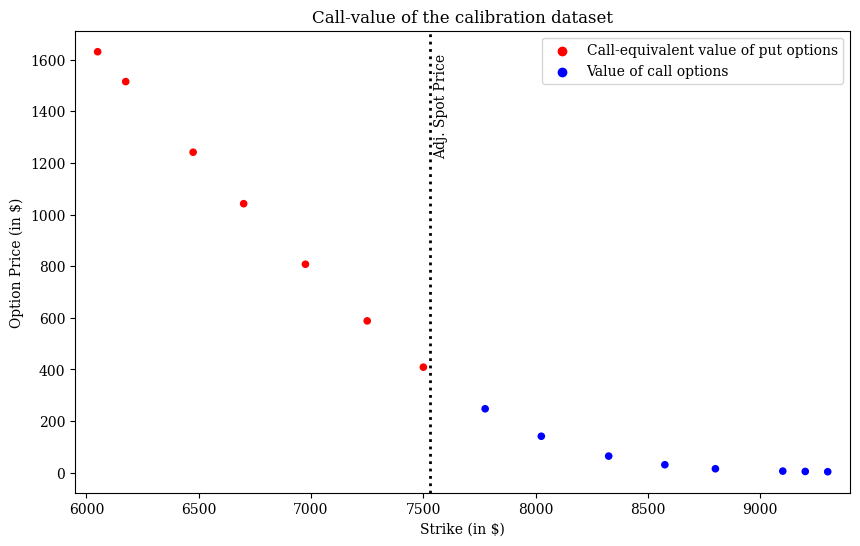

In [40]:
unique_options_expiry = calib_options_data['dte'].unique()
#===================================================================
# Plotting option prices at different strikes for given maturities
#===================================================================
DTE = unique_options_expiry[2]
options_exp_val = calib_options_data[calib_options_data['dte'].isin([DTE])]
Sadj = options_exp_val['Sadj'].unique()[0]
colors = np.where(options_exp_val['type'] == 'put', 'red', 'blue')
#===================================================================
# Scatter plot of the actual option prices listed for S&P500 index
#===================================================================
ax = options_exp_val.plot.scatter(x='strike', y='call_value', c=colors, label='Actual Call Price', figsize=(10,6))
ax.set_ylabel('Option Price')
ax.set_xlim([options_exp_val['strike'].min()-100, options_exp_val['strike'].max()+100])
ax.axvline(x=Sadj, color='black', linestyle=':', linewidth=2, label='Reference Strike')
domain1_proxy = ax.scatter([], [], color='red', label='Call-equivalent value of put options')
domain2_proxy = ax.scatter([], [], color='blue', label='Value of call options')
ax.legend(handles=[domain1_proxy, domain2_proxy])
ax.text(Sadj+20, ax.get_ylim()[1]*0.95, 'Adj. Spot Price', rotation=90, verticalalignment='top');
ax.set_ylabel(r'Option Price (in \$)')
ax.set_xlabel(r'Strike (in \$)')
ax.set_title("Call-value of the calibration dataset");

In [41]:
options_exp_val

spot  type  dte    strike  lastPrice      bid      ask  midPrice   volume  impliedVolatility  moneyness  spread_pct  inTheMoney      Sadj  \
dte                                                                                                                                                       
164 1043 7537.4302   put  164 6050.0000    52.7000  52.7000  53.6000   53.1500 101.0000             0.2538     0.8027      0.0169      0.0000 7529.3735   
    1046 7537.4302   put  164 6175.0000    60.0000  59.9000  60.8000   60.3500  37.0000             0.2441     0.8192      0.0149      0.0000 7529.3735   
    1051 7537.4302   put  164 6475.0000    82.2000  81.4000  82.6000   82.0000  58.0000             0.2210     0.8590      0.0146      0.0000 7529.3735   
    1058 7537.4302   put  164 6700.0000   103.8800 103.3000 104.7000  104.0000 216.0000             0.2035     0.8889      0.0135      0.0000 7529.3735   
    1069 7537.4302   put  164 6975.0000   138.4700 139.3000 140.8000  140.0500  15.0000             0.1816     0.9254      0.0107      0.0000 7529.3735   
    1077 7537.4302   put  164 7250.0000   193.2900 190.3000 191.9000  191.1000  34.0000             0.1590     0.9619      0.0084      0.0000 7529.3735   
    1085 7537.4302   put  164 7500.0000   254.0000 257.0000 258.7000  257.8500 421.0000             0.1375     0.9950      0.0066      0.0000 7529.3735   
    1095 7537.4302  call  164 7775.0000   250.7700 246.7000 248.6000  247.6500  25.0000             0.1728     1.0315      0.0077      0.0000 7529.3735   
    1101 7537.4302  call  164 8025.0000   141.2100 140.5000 142.1000  141.3000  14.0000             0.1583     1.0647      0.0113      0.0000 7529.3735   
    1108 7537.4302  call  164 8325.0000    66.0000  63.8000  65.1000   64.4500  34.0000             0.1474     1.1045      0.0202      0.0000 7529.3735   
    1114 7537.4302  call  164 8575.0000    30.6400  30.4000  31.5000   30.9500  14.0000             0.1422     1.1377      0.0355      0.0000 7529.3735   
    1118 7537.4302  call  164 8800.0000    15.5000  15.0000  15.7000   15.3500  38.0000             0.1395     1.1675      0.0456      0.0000 7529.3735   
    1121 7537.4302  call  164 9100.0000     6.3000   6.1000   6.5000    6.3000 128.0000             0.1397     1.2073      0.0635      0.0000 7529.3735   
    1122 7537.4302  call  164 9200.0000     4.7900   4.6000   5.1000    4.8500  12.0000             0.1411     1.2206      0.1031      0.0000 7529.3735   
    1123 7537.4302  call  164 9300.0000     3.6000   3.6000   4.1000    3.8500  10.0000             0.1430     1.2338      0.1299      0.0000 7529.3735   

          call_value  market_iv  
dte                              
164 1043   1630.6669     0.2674  
    1046   1514.8947     0.2583  
    1051   1241.4113     0.2364  
    1058   1042.0613     0.2202  
    1069    807.5723     0.2005  
    1077    588.0834     0.1812  
    1085    408.8889     0.1646  
    1095    247.6500     0.1497  
    1101    141.3000     0.1397  
    1108     64.4500     0.1327  
    1114     30.9500     0.1296  
    1118     15.3500     0.1284  
    1121      6.3000     0.1300  
    1122      4.8500     0.1314  
    1123      3.8500     0.1334

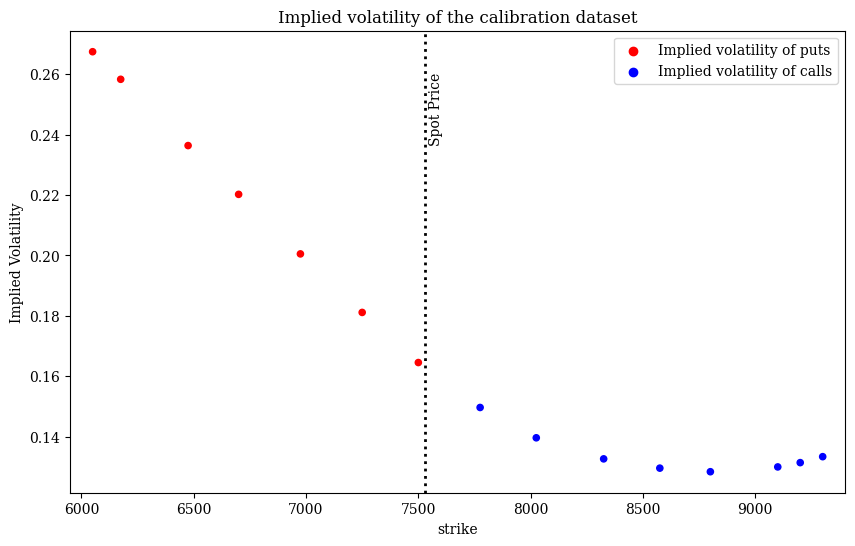

In [42]:
options_exp_val['market_iv']   = options_exp_val.apply(lambda row: implied_volatility(row['type'], row['midPrice'], row['Sadj'], row['strike'], DTE/365., r), axis=1)
#=========================================================================
# Scatter plot of the market implied volatilities for the listed options
#=========================================================================
ax2 = options_exp_val.plot.scatter(x='strike', y='market_iv', c=colors, label='Market Implied Volatility', figsize=(10,6))
ax2.set_ylabel('Implied Volatility')
ax2.set_xlim([options_exp_val['strike'].min()-100, options_exp_val['strike'].max()+100])
ax2.axvline(x=options_exp_val['Sadj'].unique()[0], color='black', linestyle=':', linewidth=2, label='Spot price')
domain1_proxy = ax2.scatter([], [], color='red', label='Implied volatility of puts')
domain2_proxy = ax2.scatter([], [], color='blue', label='Implied volatility of calls')
ax2.legend(handles=[domain1_proxy, domain2_proxy])
ax2.text(options_exp_val['Sadj'].unique()[0]+20, ax2.get_ylim()[1]*0.95, 'Spot Price', rotation=90, verticalalignment='top');
ax.set_xlabel(r'Strike (in \$)')
ax2.set_title("Implied volatility of the calibration dataset");

In [43]:
#============================================
# Calibration Functions
#============================================
i = 0
min_OMSE = 500
min_MSE = 500
sigma_market = calib_options_data['market_iv'].to_numpy()
def H93_error_function(p0):
    ''' Error function for parameter calibration in H93 model via
    Lewis (2001) Fourier approach.
    Parameters
    ==========
    kappa_v: float
    mean-reversion factor
    theta_v: float
    long-run mean of variance
    sigma_v: float
    volatility of variance
    rho: float
    correlation between variance and stock/index level
    v0: float
    initial, instantaneous variance
    Returns
    =======
    MSE: float
    mean squared error
    '''
    global i, min_MSE, min_OMSE
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    if kappa_v < 0.0 or theta_v < 0.005 or sigma_v < 0.0 or rho < -1.0 or rho > 1.0:
        return 500.0
    df = calib_options_data.copy()
    df['model_value'] = df.apply(lambda row: H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0)\
                                 if row['type']=='call' else H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0)-row['Sadj'] + row['strike']*math.exp(-r*row['dte']/365.), axis=1)
    df['model_iv'] = df.apply(lambda row: implied_volatility(row['type'], row['model_value'], row['Sadj'], row['strike'], row['dte']/365., r), axis=1) 
    sigma_model = df['model_iv'].to_numpy()
    TTM = df['dte'].to_numpy()/365.
    #feller_penalty = 0.005*max(0., 0.3 - 2*kappa_v*theta_v/sigma_v**2 )**2
    #sigma_penalty = math.pow(10., -7.)*max(0., sigma_v - 0.9)**2
    weight = np.sqrt(TTM)/np.sum(np.sqrt(TTM))
    se = np.square(sigma_market - sigma_model) *1000
    o_se = weight*se #+ feller_penalty + sigma_penalty
    se = se[sigma_market > 0.001]
    o_se = o_se[sigma_market > 0.001]
    MSE = sum(se) / len(se)
    OMSE = sum(o_se)/len(o_se)
    min_MSE = MSE if OMSE < min_OMSE else min_MSE
    min_OMSE = min(OMSE, min_OMSE)
    if i % 25 == 0:
        print('%4d |' % i, np.array(p0), '| %7.3f | %7.3f' % (MSE, min_MSE))
    i += 1
    return OMSE
def H93_calibration_full():
    ''' Calibrates H93 stochastic volatility model to market quotes. '''
    print(f"Scanning sensible regions ...")
    bounds = [(0.1, 10.0),(0.01, 0.07),(0.05, 2.),(-0.95, -0.25),(0.01, 0.09)]
    res1 = differential_evolution(H93_error_function, bounds, seed=42, maxiter=25, popsize=8,
                                  tol=1e-6, polish=False, mutation=(0.5, 1.), recombination=0.9)
    print('Global optimization ends.')
    print('Finding the local minima ...')
    res2 = minimize(H93_error_function, res1.x, method="L-BFGS-B", bounds=bounds,
                    options={"maxiter": 1000, "ftol": 1e-12, "gtol": 1e-8})
    print('Local optimization ends ...')
    return res2.x

In [44]:
#============================================
# Calibrated parameters for the Heston model
#============================================
heston_calibrated_params = H93_calibration_full()

Scanning sensible regions ...
   0 | [3.166 0.037 0.259 -0.637 0.066] |   3.882 |   3.882
  25 | [0.600 0.014 0.442 -0.890 0.048] |   0.625 |   0.101
  50 | [6.021 0.048 1.792 -0.640 0.014] |   0.023 |   0.023
  75 | [8.640 0.058 1.977 -0.706 0.012] |   0.380 |   0.023
 100 | [5.896 0.057 0.640 -0.859 0.031] |   1.498 |   0.023
 125 | [6.582 0.044 1.776 -0.757 0.025] |   0.092 |   0.023
 150 | [2.073 0.053 1.580 -0.732 0.020] |   0.663 |   0.023
 175 | [3.802 0.038 1.677 -0.709 0.039] |   0.157 |   0.009
 200 | [8.280 0.056 1.725 -0.682 0.087] |   3.193 |   0.009
 225 | [7.602 0.041 1.799 -0.712 0.011] |   0.149 |   0.008
 250 | [5.140 0.048 1.602 -0.665 0.020] |   0.016 |   0.008
 275 | [6.746 0.045 1.663 -0.697 0.020] |   0.011 |   0.008
 300 | [7.118 0.040 1.640 -0.556 0.024] |   0.081 |   0.008
 325 | [9.456 0.042 1.737 -0.689 0.014] |   0.022 |   0.008
 350 | [8.325 0.044 1.833 -0.729 0.017] |   0.031 |   0.008
 375 | [9.060 0.045 1.975 -0.688 0.014] |   0.012 |   0.008
 400 | [7.

In [45]:
kappa_v, theta_v, sigma_v, rho, v0 = heston_calibrated_params
np.save('../options_data/Heston_parameters_SPX.npy', [kappa_v, theta_v, sigma_v, rho, v0])
feller_ratio = (2 * kappa_v * theta_v) / (sigma_v ** 2)
calib_options_data['model_value'] = calib_options_data.apply(lambda row: H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0)\
                                 if row['type']=='call' else H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0)-row['Sadj'] + row['strike']*math.exp(-r*row['dte']/365.), axis=1)
calib_options_data['model_iv'] = calib_options_data.apply(lambda row: implied_volatility(row['type'], row['model_value'], row['Sadj'], row['strike'], row['dte']/365., r), axis=1)
IV_RMSE = np.sqrt(np.mean(np.square(calib_options_data['model_iv'].to_numpy() - calib_options_data['market_iv'].to_numpy())))

display(Math(rf"\text{{The calibrated Heston model parameters are:}}"))
display(Math(rf"\kappa_v = {kappa_v:.3f}"))
display(Math(rf"\theta_v = {theta_v:.3f}"))
display(Math(rf"\sigma_v = {sigma_v:.3f}"))
display(Math(rf"\rho = {rho:.3f}"))
display(Math(rf"v_0 = {v0:.3f}"))
display(Math(rf"\text{{with an implied volatility RMSE of }} {IV_RMSE:.4f}."))
display(Math(rf"\text{{The corresponding Feller ratio is equal to }} {feller_ratio:.4f}."))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The calibration objective exhibits substantial parameter degeneracy, particularly in κ and σ. Economically motivated bounds were imposed to stabilize the optimization and improve parameter interpretability. The calibrated parameters usually imply a Feller ratio in the range $0.2-0.3$, indicating that the CIR variance process may attain zero with positive probability. Although this violates the sufficient condition for strict positivity of the variance, $v$ , such violations are common in equity-index Heston calibrations and are often necessary to reproduce the observed SPX implied volatility skew.

In [46]:
def H93_calculate_model_values(df, p0):
    ''' Calculates all model values given parameter vector p0 and adds into the options_data dataframe. '''
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    df['model_value'] = df.apply(lambda row: H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0) \
                                 if row['type']=='call' else H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0)\
                                 - row['Sadj'] + row['strike']*math.exp(-r*row['dte']/365.), axis=1)
def H93_calculate_call_values(df, p0):
    ''' Calculates all model values given parameter vector p0 and adds into the options_data dataframe. '''
    kappa_v, theta_v, sigma_v, rho, v0 = p0
    df['call_value'] = df.apply(lambda row: H93_call_value(row['Sadj'], row['strike'], row['dte']/365., r, kappa_v, theta_v, sigma_v, rho, v0), axis=1)

In [47]:
#=================================================================
# Calculating the option prices determined from the Heston model
#=================================================================
H93_calculate_model_values(options_data, [kappa_v, theta_v, sigma_v, rho, v0])
H93_calculate_call_values(options_data, [kappa_v, theta_v, sigma_v, rho, v0])

In [48]:
full_options_data

,spot,type,dte,strike,lastPrice,bid,ask,midPrice,volume,impliedVolatility,inTheMoney,Sadj
358,7537.4302,put,1,3400.0000,0.0500,0.0000,0.0500,0.0250,1.0000,2.8906,0.0000,NaN
359,7537.4302,put,1,3600.0000,0.1000,0.0000,0.0500,0.0250,10.0000,2.6875,0.0000,NaN
360,7537.4302,put,1,3800.0000,0.1000,0.0000,0.0500,0.0250,1.0000,2.5000,0.0000,NaN
361,7537.4302,put,1,4000.0000,0.1000,0.0000,0.0500,0.0250,1.0000,2.3125,0.0000,NaN
362,7537.4302,put,1,4200.0000,0.1000,0.0000,0.0500,0.0250,2.0000,2.1484,0.0000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18985,7537.4302,put,1991,16000.0000,5465.4800,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,NaN
18986,7537.4302,call,1991,18000.0000,45.1600,0.0000,0.0000,0.0000,1.0000,0.0625,0.0000,NaN
18987,7537.4302,put,1991,18000.0000,6865.6400,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,NaN
18988,7537.4302,call,1991,20000.0000,28.7000,0.0000,0.0000,0.0000,79.0000,0.0625,0.0000,NaN


In [49]:
full_options_data['call_value'] = full_options_data.apply(lambda row: row['midPrice'] if row['type']=='call' \
                                                         else row['midPrice'] + row['Sadj'] -row['strike']*math.exp(-r*row['dte']/365.), axis=1)

unique_options_expiry = options_data['dte'].unique()
unique_options_expiry

array([31.000, 38.000, 45.000, 52.000, 55.000, 73.000, 85.000, 101.000,
       115.000, 136.000, 164.000, 177.000, 192.000, 227.000, 255.000,
       267.000, 283.000])

In [50]:
options_exp_val

spot  type  dte    strike  lastPrice      bid      ask  midPrice   volume  impliedVolatility  moneyness  spread_pct  inTheMoney      Sadj  \
dte                                                                                                                                                       
164 1043 7537.4302   put  164 6050.0000    52.7000  52.7000  53.6000   53.1500 101.0000             0.2538     0.8027      0.0169      0.0000 7529.3735   
    1046 7537.4302   put  164 6175.0000    60.0000  59.9000  60.8000   60.3500  37.0000             0.2441     0.8192      0.0149      0.0000 7529.3735   
    1051 7537.4302   put  164 6475.0000    82.2000  81.4000  82.6000   82.0000  58.0000             0.2210     0.8590      0.0146      0.0000 7529.3735   
    1058 7537.4302   put  164 6700.0000   103.8800 103.3000 104.7000  104.0000 216.0000             0.2035     0.8889      0.0135      0.0000 7529.3735   
    1069 7537.4302   put  164 6975.0000   138.4700 139.3000 140.8000  140.0500  15.0000             0.1816     0.9254      0.0107      0.0000 7529.3735   
    1077 7537.4302   put  164 7250.0000   193.2900 190.3000 191.9000  191.1000  34.0000             0.1590     0.9619      0.0084      0.0000 7529.3735   
    1085 7537.4302   put  164 7500.0000   254.0000 257.0000 258.7000  257.8500 421.0000             0.1375     0.9950      0.0066      0.0000 7529.3735   
    1095 7537.4302  call  164 7775.0000   250.7700 246.7000 248.6000  247.6500  25.0000             0.1728     1.0315      0.0077      0.0000 7529.3735   
    1101 7537.4302  call  164 8025.0000   141.2100 140.5000 142.1000  141.3000  14.0000             0.1583     1.0647      0.0113      0.0000 7529.3735   
    1108 7537.4302  call  164 8325.0000    66.0000  63.8000  65.1000   64.4500  34.0000             0.1474     1.1045      0.0202      0.0000 7529.3735   
    1114 7537.4302  call  164 8575.0000    30.6400  30.4000  31.5000   30.9500  14.0000             0.1422     1.1377      0.0355      0.0000 7529.3735   
    1118 7537.4302  call  164 8800.0000    15.5000  15.0000  15.7000   15.3500  38.0000             0.1395     1.1675      0.0456      0.0000 7529.3735   
    1121 7537.4302  call  164 9100.0000     6.3000   6.1000   6.5000    6.3000 128.0000             0.1397     1.2073      0.0635      0.0000 7529.3735   
    1122 7537.4302  call  164 9200.0000     4.7900   4.6000   5.1000    4.8500  12.0000             0.1411     1.2206      0.1031      0.0000 7529.3735   
    1123 7537.4302  call  164 9300.0000     3.6000   3.6000   4.1000    3.8500  10.0000             0.1430     1.2338      0.1299      0.0000 7529.3735   

          call_value  market_iv  
dte                              
164 1043   1630.6669     0.2674  
    1046   1514.8947     0.2583  
    1051   1241.4113     0.2364  
    1058   1042.0613     0.2202  
    1069    807.5723     0.2005  
    1077    588.0834     0.1812  
    1085    408.8889     0.1646  
    1095    247.6500     0.1497  
    1101    141.3000     0.1397  
    1108     64.4500     0.1327  
    1114     30.9500     0.1296  
    1118     15.3500     0.1284  
    1121      6.3000     0.1300  
    1122      4.8500     0.1314  
    1123      3.8500     0.1334

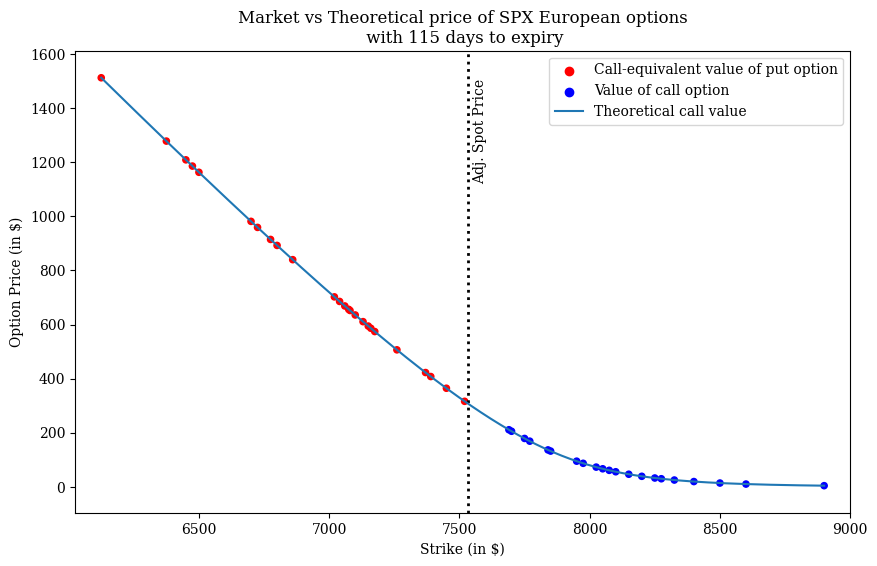

In [51]:
#===================================================================
# Plotting option prices at different strikes for given maturities
#===================================================================
DTE = unique_options_expiry[8]
options_exp_val = options_data[options_data['dte'].isin([DTE])]
Sadj = options_exp_val['Sadj'].unique()[0]
colors = np.where(options_exp_val['type'] == 'put', 'red', 'blue')
#===================================================================
# Scatter plot of the actual option prices listed for S&P500 index
#===================================================================
ax = options_exp_val.plot.scatter(x='strike', y='call_value', c=colors, figsize=(10,6))
ax.set_xlim([options_exp_val['strike'].min()-100, options_exp_val['strike'].max()+100])
ax.axvline(x=Sadj, color='black', linestyle=':', linewidth=2)
ax.text(Sadj+20, ax.get_ylim()[1]*0.95, 'Adj. Spot Price', rotation=90, verticalalignment='top')
heston_fitted_data = pd.DataFrame()
#==========================================================================================
# Plotting option prices predicted by the Fourier pricing method in a Heston SV framework
#==========================================================================================
heston_fitted_data['strike'] = np.linspace(options_exp_val['strike'].min(), options_exp_val['strike'].max(), 500)
heston_fitted_data['call_value'] = heston_fitted_data.apply(lambda row: H93_call_value(Sadj, row['strike'], DTE/365., r, kappa_v, theta_v, sigma_v, rho, v0), axis=1)
ax.set_ylim([heston_fitted_data['call_value'].min()-100, heston_fitted_data['call_value'].max()+100])
domain1_proxy = ax.scatter([], [], color='red', label='Call-equivalent value of put option')
domain2_proxy = ax.scatter([], [], color='blue', label='Value of call option')
ax.legend(handles=[domain1_proxy, domain2_proxy])
ax.set_ylabel(r'Option Price (in \$)')
heston_fitted_data.plot(x='strike', y='call_value', kind='line', ax=ax, label='Theoretical call value');
ax.set_xlabel(r'Strike (in \$)')
ax.set_title(f"Market vs Theoretical price of SPX European options\n with {DTE} days to expiry");

In [52]:
heston_fitted_data['type'] = heston_fitted_data.apply(lambda row: 'call' if row['strike'] > Sadj else 'put', axis=1)
options_exp_val = options_exp_val[options_exp_val['midPrice']>0.01]

In [53]:
heston_fitted_data = heston_fitted_data[(heston_fitted_data['call_value']>0.0001) & (heston_fitted_data['call_value']-options_exp_val['Sadj'].unique()[0]+heston_fitted_data['strike']*math.exp(-r*DTE/365.)>0.0001)]

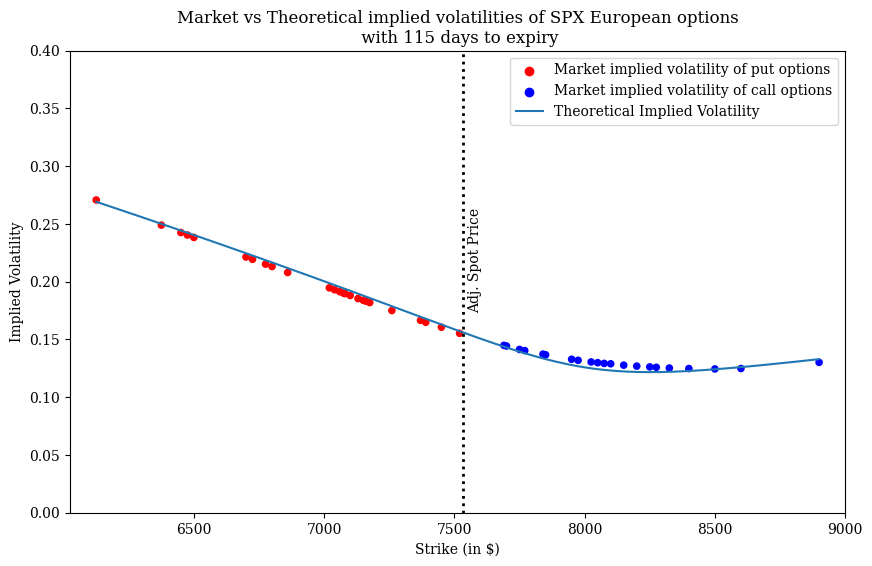

In [54]:
options_exp_val['market_iv']   = options_exp_val.apply(lambda row: implied_volatility(row['type'], row['midPrice'], row['Sadj'], row['strike'], DTE/365., r) if row['midPrice']>0.00001 else 0.000001, axis=1)
heston_fitted_data['model_iv'] = heston_fitted_data.apply(lambda row: implied_volatility(row['type'], row['call_value'], options_exp_val['Sadj'].unique()[0], row['strike'], DTE/365., r)\
                                                          if row['type']=='call' else implied_volatility(row['type'], row['call_value']-options_exp_val['Sadj'].unique()[0]+row['strike']*math.exp(-r*DTE/365.),\
                                                                             options_exp_val['Sadj'].unique()[0], row['strike'], DTE/365., r), axis=1)
colors = np.where(options_exp_val['type'] == 'put', 'red', 'blue')
#=========================================================================
# Scatter plot of the market implied volatilities for the listed options
#=========================================================================
ax2 = options_exp_val.plot.scatter(x='strike', y='market_iv', c=colors, figsize=(10, 6))
ax2.set_ylabel('Implied Volatility')
ax2.set_xlabel('Strike')
ax2.set_xlim([options_exp_val['strike'].min()-100, options_exp_val['strike'].max()+100])
ax2.axvline(x=options_exp_val['Sadj'].unique()[0], color='black', linestyle=':', linewidth=2)
ax2.text(options_exp_val['Sadj'].unique()[0]+20, ax2.get_ylim()[1]*0.95, 'Adj. Spot Price', rotation=90, verticalalignment='top')
domain1_proxy = ax2.scatter([], [], color='red', label='Market implied volatility of put options')
domain2_proxy = ax2.scatter([], [], color='blue', label='Market implied volatility of call options')
ax2.legend(handles=[domain1_proxy, domain2_proxy])
#==============================================
# Plotting Heston model implied volatilities
#==========================================================================================
heston_fitted_data.plot(x='strike', y='model_iv', kind='line', ax=ax2, label='Theoretical Implied Volatility');
ax2.set_ylim([0., 0.4])
ax2.set_ylabel('Implied Volatility')
ax2.set_xlabel(r'Strike (in \$)')
ax2.set_title(f"Market vs Theoretical implied volatilities of SPX European options\n with {DTE} days to expiry"); 
ax2.get_figure().savefig('../figures/iv_calibrated_plot.png', dpi=300, bbox_inches='tight')

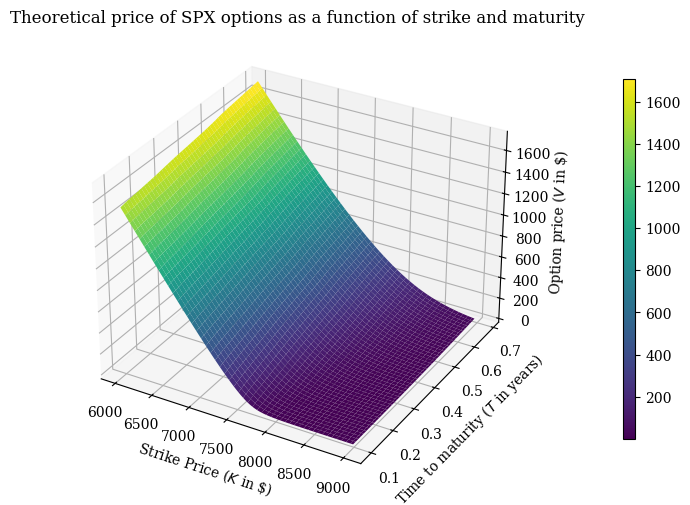

In [55]:
#=============================================================================
# Plotting option price surface as a function of spot price and maturity
#=============================================================================
K_vec = np.linspace(options_exp_val['strike'].min()-100, options_exp_val['strike'].max()+100, 100)
T_vec = 1/365. * np.linspace(35., 250., 50)
K_grid, T_grid = np.meshgrid(K_vec, T_vec, indexing='ij')
H93_surface_value = np.zeros((len(K_vec), len(T_vec)), dtype=float)
IV_surface = np.zeros((len(K_vec), len(T_vec)), dtype=float)
for j, T_val in enumerate(T_vec):
    Sadj = Sadj_interp_curve(int(365*T_val))
    for i, K_val in enumerate(K_vec):
        H93_surface_value[i, j] = H93_call_value(Sadj, K_val, T_val, r, \
                                                 kappa_v, theta_v, sigma_v, rho, v0)
        IV_surface[i, j] = implied_volatility('call', H93_surface_value[i, j], Sadj, K_val, T_val, r) if K_val>Sadj \
                           else implied_volatility('put', H93_surface_value[i, j] - Sadj + K_val*math.exp(-r*T_val), \
                                                   Sadj, K_val, T_val, r)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K_grid, T_grid, H93_surface_value, cmap='viridis', edgecolor='none')
ax.set_xlabel(r'Strike Price ($K$ in \$)')
ax.set_ylabel(r'Time to maturity ($T$ in years)')
ax.set_zlabel(r'Option price ($V$ in \$)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, cax=fig.add_axes([0.92, 0.2, 0.015, 0.6]))
ax.set_title("Theoretical price of SPX options as a function of strike and maturity");
plt.show()

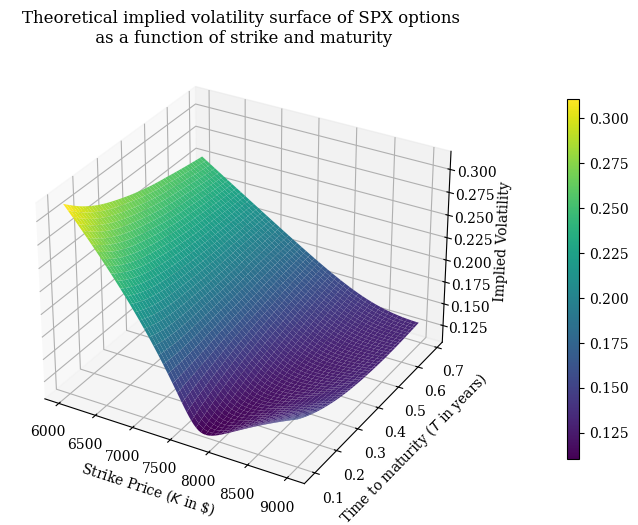

In [56]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K_grid, T_grid, IV_surface, cmap='viridis', edgecolor='none')
ax.set_xlabel(r'Strike Price ($K$ in \$)')
ax.set_ylabel(r'Time to maturity ($T$ in years)')
ax.set_zlabel(r'Implied Volatility')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, cax=fig.add_axes([0.92, 0.2, 0.015, 0.6]))
ax.set_title("Theoretical implied volatility surface of SPX options\n as a function of strike and maturity");
plt.show()

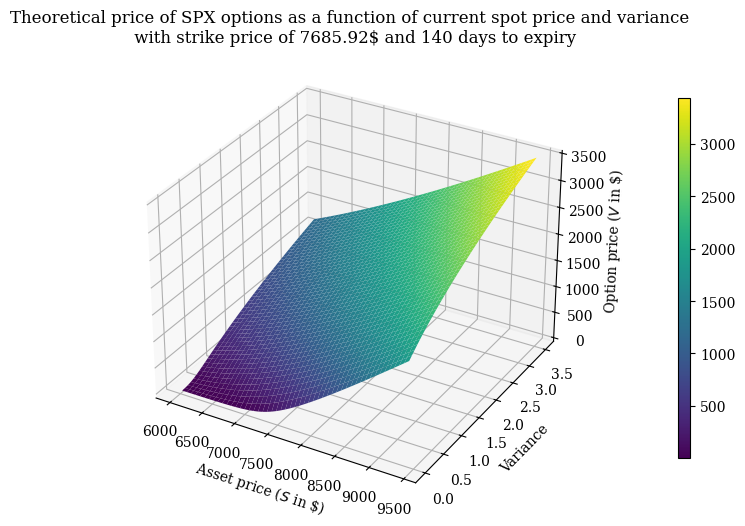

In [57]:
#=============================================================================
# Plotting option price surface as a function of spot price and inital
# variance with a specific strike and maturity
#=============================================================================
T_val = 140/365.
K_val = 1.02*Sadj
S_vec = np.linspace(0.8*S0, 1.25*S0, 50)
v_vec = np.linspace(0., 3.5, 50)
ds = S_vec[1:] - S_vec[:-1]
dv = v_vec[1:] - v_vec[:-1]
S_grid, v_grid = np.meshgrid(S_vec, v_vec, indexing='ij')
Price_surface = np.zeros((len(S_vec), len(v_vec)), dtype=float)
Delta_surface = np.zeros((len(S_vec), len(v_vec)), dtype=float)
Vega_surface = np.zeros((len(S_vec), len(v_vec)), dtype=float)
for j, v_val in enumerate(v_vec):
    for i, S_val in enumerate(S_vec):
        Price_surface[i, j] = H93_call_value(S_val, K_val, T_val, r, \
                                                 kappa_v, theta_v, sigma_v, rho, v_val)
        pass
    pass

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_grid, v_grid, Price_surface, cmap='viridis', edgecolor='none')
ax.set_xlabel(r'Asset price ($S$ in \$)')
ax.set_ylabel(r'Variance')
ax.set_zlabel(r'Option price ($V$ in \$)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, cax=fig.add_axes([0.92, 0.2, 0.015, 0.6]))
ax.set_title(f"Theoretical price of SPX options as a function of current spot price and variance \n with strike price of {round(K_val, 2)}\$ and {int(T_val*365)} days to expiry");
plt.show()

### Greeks

Greeks quantify the sensitivity of an option's value to changes in underlying market variables and are fundamental tools for risk management, hedging, and trading. They provide insight into how an option portfolio is expected to respond to small market movements and are therefore as important as the option price itself.

Delta ($\Delta$) measures the sensitivity of the option value to changes in the underlying asset price,
$$\Delta = \frac{\partial V}{\partial S}$$
It represents the approximate change in the option price resulting from a one-unit change in the underlying asset price. Delta is the primary measure used for hedging directional market risk and indicates the effective exposure of the option position to movements in the underlying asset.

Vega ($\nu$) measures the sensitivity of the option value to changes in volatility,
$$\nu = \frac{\partial V}{\partial \sigma}$$
It quantifies the change in the option price associated with a small change in the market's expectation of future volatility. Vega is particularly important in stochastic-volatility models such as Heston, where volatility is itself a dynamic state variable. It provides a measure of an option's exposure to volatility risk and is widely used in volatility trading and risk management.

Together, Delta and Vega describe the option's sensitivity to the two most important sources of uncertainty in the Heston framework: movements in the underlying asset price and changes in volatility. Consequently, they play a central role in both pricing validation and the construction of hedging strategies.

---

### Delta and Vega in the Heston Stochastic Volatility Framework

In the Heston stochastic volatility (SV) model, both Delta and Vega exhibit richer structure compared to the Black–Scholes framework due to the presence of a stochastic variance process.

Here, Delta becomes explicitly dependent on the current variance state. As a result, the Delta surface is smooth but non-linear in moneyness, and its shape is strongly influenced by the instantaneous volatility level. Higher variance leads to a flatter transition between in-the-money and out-of-the-money regions, while the correlation parameter introduces asymmetry between call and put sensitivities, contributing to the observed volatility skew.

Vega is typically highest for at-the-money options and increases with maturity, reflecting the greater impact of future variance uncertainty over longer time horizons. It is also strongly influenced by the volatility-of-volatility parameter, which controls the dispersion of volatility dynamics and amplifies sensitivity across strikes. Additionally, the correlation between the asset and variance processes induces a skew in the Vega surface, making downside strikes more sensitive in equity-like markets with negative correlation.

Together, Delta and Vega capture the two dominant sources of risk in the Heston framework: directional exposure to the underlying asset and exposure to stochastic volatility dynamics.

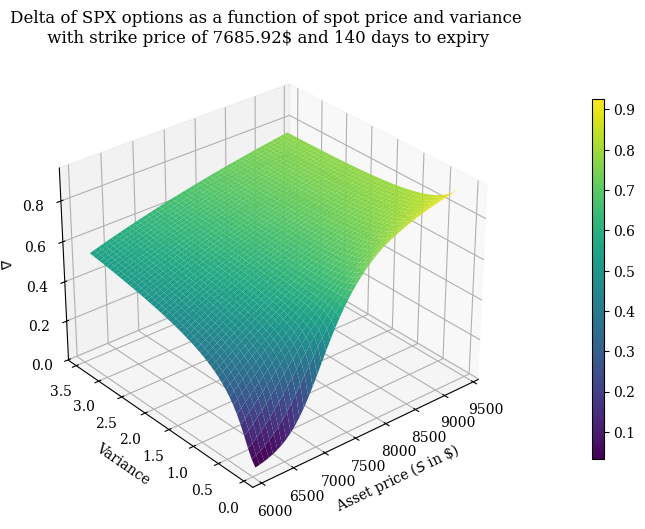

In [58]:
#=============================================================================
# Plotting delta surface as a function of spot price and inital
# variance with a specific strike and maturity
#=============================================================================
S_grid, v_grid = np.meshgrid(S_vec[1: -1], v_vec[1: -1], indexing='ij')
c1 = -ds[1:]/(ds[:-1]*(ds[:-1] + ds[1:]))
c2 = (ds[1:] - ds[:-1])/(ds[:-1]*ds[1:])
c3 = ds[:-1]/(ds[1:]*(ds[:-1]+ds[1:]))
Delta_surface[1: -1, :] = c1[:, None]*Price_surface[:-2, :] \
                        + c2[:, None]*Price_surface[1:-1, :] + c3[:, None]*Price_surface[2:, :]
Delta_surface[-1, :] = 1. 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_grid, v_grid, Delta_surface[1:-1, 1:-1], cmap='viridis', edgecolor='none')
ax.set_xlabel(r'Asset price ($S$ in \$)')
ax.set_ylabel(r'Variance')
ax.set_zlabel(r'$\Delta$')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, cax=fig.add_axes([0.92, 0.2, 0.015, 0.6]))
ax.set_title(f"Delta of SPX options as a function of spot price and variance\n with strike price of {round(K_val, 2)}\$ and {int(T_val*365)} days to expiry");
ax.view_init(azim=230)
plt.show()

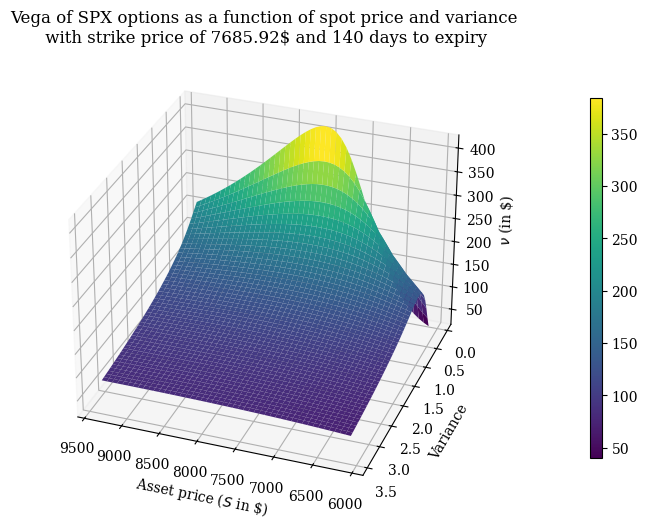

In [59]:
#=============================================================================
# Plotting vega surface as a function of spot price and inital
# variance with a specific strike and maturity
#=============================================================================
dvol = np.sqrt(dv)
b1 = - dvol[1:]/(dvol[:-1]*(dvol[:-1] + dvol[1:]))
b2 = (dvol[1:] - dvol[:-1])/(dvol[1:] * dvol[:-1])
b3 = dvol[:-1]/(dvol[1:]*(dvol[:-1] + dvol[1:]))
Vega_surface[:, 1: -1] = b1[None, :]*Price_surface[:, :-2] \
+ b2[None, :]*Price_surface[:, 1:-1] + b3[None, :]*Price_surface[:, 2:]
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S_grid, v_grid, Vega_surface[1: -1, 1: -1], cmap='viridis', edgecolor='none')
ax.set_xlabel(r'Asset price ($S$ in \$)')
ax.set_ylabel(r'Variance')
ax.set_zlabel(r'$\nu$ (in \$)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, cax=fig.add_axes([0.92, 0.2, 0.015, 0.6]))
ax.set_title(f"Vega of SPX options as a function of spot price and variance\n with strike price of {round(K_val, 2)}\$ and {int(T_val*365)} days to expiry");
ax.view_init(azim=110)
plt.show()